# Week 6: Transformer Attention and Rotary Position Encoding

This notebook builds attention from scratch, contrasts traditional positional encoding with rotary positional encoding (`RoPE`), and assembles a reusable Transformer block with both self-attention and cross-attention.

## Learning Goals
- Understand scaled dot-product attention and the role of `Query`, `Key`, and `Value`.
- Compare traditional additive positional encoding with rotary positional encoding.
- Build a Transformer block with residual connections, layer normalization, self-attention, and feed-forward layers.
- Extend the same block with cross-attention.
- Visualize attention weights in color so we can inspect where information flows.
- Reuse the saved IMDb tokenized dataset for a small Transformer encoder classifier setup.

## Reused Assets and Small Demo Data
This week reuses the saved IMDb tokenized assets from the previous weeks so the modeling comparison stays consistent.

- `../week5-CNN-for-text/data/imdb_bpe_dataset.pt`
- `../week5-CNN-for-text/data/bpe_vocab.json`
- `../week5-CNN-for-text/models/vocab_config.json`

For cross-attention, we also use a tiny handwritten paired-text probe so we can demonstrate encoder-decoder style attention without needing a full seq2seq dataset yet.

## Suggested Multi-Day Flow
- **Day 1:** Build intuition for scaled dot-product self-attention and inspect a heatmap.
- **Day 2:** Compare traditional positional encoding with rotary positional encoding (`RoPE`).
- **Day 3:** Assemble a Transformer block with residual connections, layer norm, and feed-forward layers.
- **Day 4:** Add cross-attention and test it on a tiny handwritten paired-text probe.
- **Day 5:** Reuse the same components for a compact IMDb Transformer encoder classifier.

You can treat each day as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from utils import (
    MultiHeadAttention,
    TinyTransformerClassifier,
    TransformerBlock,
    apply_rope,
    batch_encode_word_sequences,
    build_rope_cache,
    build_word_vocab,
    get_device,
    load_json,
    load_torch_dataset,
    plot_attention_heads,
    plot_attention_heatmap,
    scaled_dot_product_attention,
    sinusoidal_position_encoding,
    train_binary_classifier,
)


In [2]:
paths = {
    "dataset": Path("../week5-CNN-for-text/data/imdb_bpe_dataset.pt"),
    "bpe_vocab": Path("../week5-CNN-for-text/data/bpe_vocab.json"),
    "vocab_config": Path("../week5-CNN-for-text/models/vocab_config.json"),
    "dan_state": Path("../week5-CNN-for-text/models/dan_imdb.pt"),
}

missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Week 6 assets:\n" + "\n".join(missing))

input_ids, labels, attention_masks = load_torch_dataset(str(paths["dataset"]))
bpe_vocab = load_json(str(paths["bpe_vocab"]))
vocab_config = load_json(str(paths["vocab_config"]))
id_to_token = {idx: token for token, idx in bpe_vocab.items()}
device = get_device()

print("device:", device)
print("input_ids shape:", tuple(input_ids.shape))
print("labels shape:", tuple(labels.shape))
print("attention_masks shape:", tuple(attention_masks.shape))
print("vocab size:", vocab_config["vocab_size"])
print("pad id:", vocab_config["pad_id"])


device: mps
input_ids shape: (50000, 128)
labels shape: (50000,)
attention_masks shape: (50000, 128)
vocab size: 590
pad id: 589


## Day 1: Attention Foundations
The goal for Day 1 is to understand what attention is doing mechanically before we add position information or stack multiple sublayers.

### Self-Attention Intuition
A self-attention layer lets each token build a weighted summary of the other tokens in the same sequence. The weights come from similarity between `query` and `key`, while the content being aggregated comes from `value`. In matrix form, scaled dot-product self-attention is

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

where `Q`, `K`, and `V` all come from the same token sequence in the self-attention case.

For the first demo, we reuse the learned Week 5 `DAN` embedding weights so the token representations are not random. We also start with a projection-free version where `Q = K = V = token states` and call `scaled_dot_product_attention` directly, because the attention heatmap should visualize the attention weights themselves before we add learned projection layers in later cells.

This first visualization uses a single attention head only. We do not split the `384`-dimensional token state into multiple heads yet, so the extra head axis in the tensor shape is just a size-1 placeholder to match the attention function API. Multi-head splitting comes later.

This first self-attention demo also has no positional information at all. The attention scores depend only on content similarity between token vectors, not on token order or distance, which is exactly why we need positional encoding in the next section.

Because this demo does not use trained `Q`, `K`, or `V` projection layers, the attention scores are based directly on similarities between the fixed Week 5 token embeddings. In that sense, this first heatmap is mostly showing scaled static embedding similarity, not a learned attention pattern.

One easy-to-miss detail: even when a token is compared with itself, its final attention weight is not automatically `1`. Scaling divides every score in the row by the same `sqrt(d)` factor, and then softmax normalizes that token's self-score together with all of its scores against the other tokens. So a diagonal entry is only close to `1` if that self-score is much larger than the rest of the row.

Important caution: even with a learned embedding matrix, this is still not a trained attention layer. The displayed attention weights come from raw dot products on the current token states, so the heatmap is useful for understanding the mechanics of scaling, masking, and weighted averaging, but it should not be trusted as a meaningful explanation of what the model has learned. Once we introduce random `Q`, `K`, and `V` projection layers later, the heatmap becomes even less semantically interpretable until training has happened.

When the same sequence produces `Q`, `K`, and `V`, we call it **self-attention**.


sample tokens: ['82', '101', '116', '117114', '110</w>', '116', '111</w>', '67', '9798', '105110</w>', '98', '121</w>']
token states: (1, 12, 384)
query shape: (1, 1, 12, 384)
key shape: (1, 1, 12, 384)
value shape: (1, 1, 12, 384)
attention scores: (1, 1, 12, 12)
attention weights: (1, 1, 12, 12)
attention output: (1, 1, 12, 384)
head 0, first query weights: tensor([0.8195, 0.0221, 0.0131, 0.0148, 0.0208, 0.0131, 0.0113, 0.0168, 0.0184,
        0.0140, 0.0207, 0.0154])


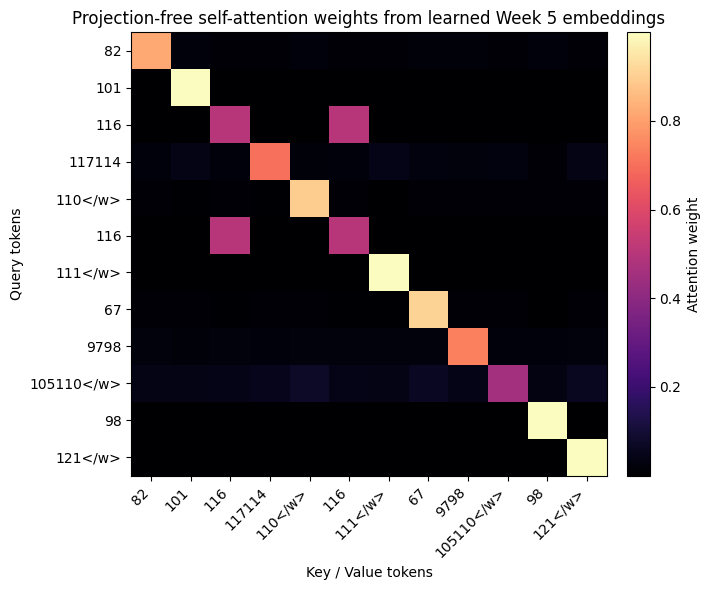

In [3]:
dan_state = torch.load(paths["dan_state"], map_location=device, weights_only=True)
embedding_weight = dan_state["embedding.weight"].to(device)
embedding_dim = embedding_weight.size(1)

# Pick one real IMDb example and trim to a short non-pad prefix for visualization.
sample_index = 204
sample_length = int(attention_masks[sample_index].sum().item())
display_len = min(12, sample_length)
sample_ids = input_ids[sample_index : sample_index + 1, :display_len].to(device)
sample_mask = attention_masks[sample_index : sample_index + 1, :display_len].to(device)
sample_tokens = [id_to_token[int(token_id)] for token_id in sample_ids[0].tolist()]

token_states = embedding_weight[sample_ids]
query = token_states.unsqueeze(1)
key = token_states.unsqueeze(1)
value = token_states.unsqueeze(1)
attention_mask = sample_mask.to(dtype=torch.bool).unsqueeze(1).unsqueeze(1)

attention_output, attention_weights = scaled_dot_product_attention(
    query=query,
    key=key,
    value=value,
    attention_mask=attention_mask,
    dropout_p=0.0,
    training=False,
)

score_scale = embedding_dim ** -0.5
attention_scores = torch.matmul(query, key.transpose(-2, -1)) * score_scale
attention_scores = attention_scores.masked_fill(~attention_mask, torch.finfo(attention_scores.dtype).min)

print("sample tokens:", sample_tokens)
print("token states:", tuple(token_states.shape))
print("query shape:", tuple(query.shape))
print("key shape:", tuple(key.shape))
print("value shape:", tuple(value.shape))
print("attention scores:", tuple(attention_scores.shape))
print("attention weights:", tuple(attention_weights.shape))
print("attention output:", tuple(attention_output.shape))
print("head 0, first query weights:", attention_weights[0, 0, 0].detach().cpu())

plot_attention_heatmap(
    attention_weights,
    sample_tokens,
    key_tokens=None,
    title="Projection-free self-attention weights from learned Week 5 embeddings",
    head=0,
    batch_idx=0,
)


## Day 2: Position Information
Now that the attention mechanism itself is clear, the next question is how the model knows token order. We start with the original additive approach and then move to rotary encoding.

### Why Position Encoding Exists
Self-attention by itself is permutation-equivariant: if we reorder the input tokens and apply the same reordering to the outputs, the attention computation is unchanged. So without positional information, token order is invisible to the model. Position encoding is what breaks that symmetry so the model can learn order-sensitive patterns such as negation scope, phrase structure, and long-range dependencies.

It is useful to compare this with earlier architectures:
- `RNN`s have sequential order baked in because hidden state is updated token by token.
- `CNN`s get locality from finite convolution windows, but not a full notion of arbitrary sequence position unless we add something else.
- plain self-attention sees all tokens at once, but without PE it only sees content similarity.

There is also a helpful mathematical intuition for sinusoidal encodings. For one frequency $\omega$, using paired sine and cosine coordinates means two positions interact through identities like

$$
\sin(\omega p_1)\sin(\omega p_2) + \cos(\omega p_1)\cos(\omega p_2) = \cos(\omega (p_1 - p_2))
$$

So the dot product between two positional vectors naturally depends on their relative offset. Another way to say this is that there is a fixed linear transformation `R(k)` such that shifting a position by `k` steps corresponds to a deterministic rotation:

$$
PE(pos + k) = R(k) \; PE(pos)
$$

That gives the model a reusable way to reason about positional shifts, even before we learn any task-specific attention projections.


### Traditional Positional Encoding
The original Transformer adds a position vector to the token embedding once near the input. This lets the model know where a token is, but the positional information is injected additively rather than directly modifying the attention geometry in every block.

The sinusoidal positional encoding used in the original paper is

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right), \qquad
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

where `pos` is the token position and `i` indexes pairs of embedding dimensions. The full input to the model is then formed by adding token embeddings and positional encodings:

$$
x_{pos} = e_{pos} + PE(pos)
$$

There is also a useful intuition behind the even/odd pairing of sine and cosine. Because

$$
\cos(A-B) = \cos A \cos B + \sin A \sin B
$$

a model can combine the sine and cosine coordinates from two positions to reason about relative offsets between them. This is one reason sinusoidal encodings can support position comparisons without learning a separate table of position embeddings.

Another design detail is that the early embedding dimensions oscillate quickly while the later ones oscillate much more slowly. That happens because the denominator `10000^{2i / d_{model}}` grows with `i`, so higher dimensions change more gradually across positions. The result is a bank of waves at different frequencies: some capture fine local shifts and others capture broader position patterns.

Because these values are deterministic, we can precompute and cache them once for a chosen maximum sequence length and then reuse them across batches, which makes inference and training cheaper. But that convenience also exposes a limitation: the encoding is defined only up to the maximum cached length, so it can become a hard context-window constraint unless we rebuild or extend the cache.

A second limitation is architectural rather than computational. This positional information is injected only once near the input by addition, so after many Transformer blocks the model has to preserve that signal indirectly inside its hidden states. In practice that means the original positional signal can become diluted or harder to recover compared with methods like RoPE that reintroduce position structure directly inside every attention computation.


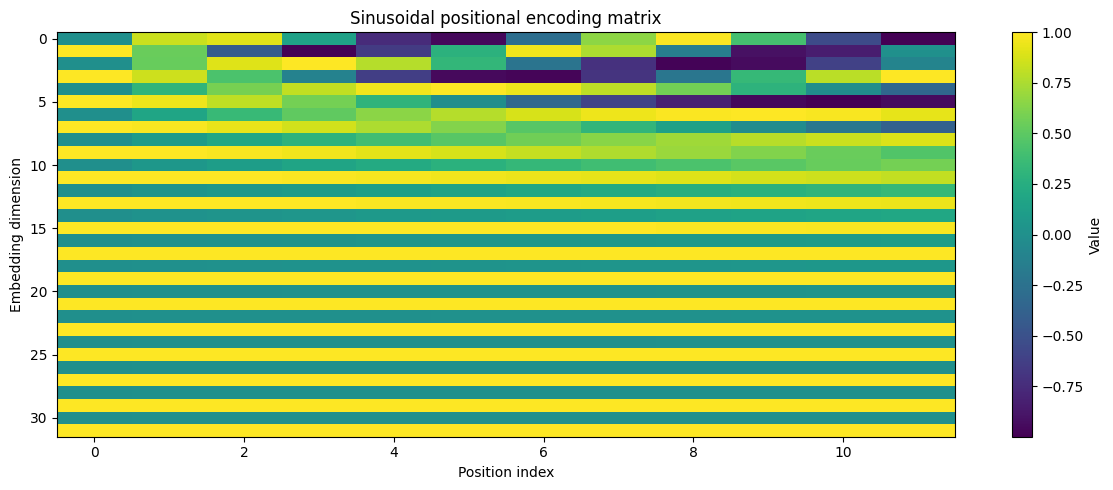

In [4]:
pe = sinusoidal_position_encoding(seq_len=12, d_model=32)

plt.figure(figsize=(12, 5))
plt.imshow(pe.T, aspect="auto", cmap="viridis")
plt.colorbar(label="Value")
plt.xlabel("Position index")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal positional encoding matrix")
plt.tight_layout()
plt.show()


### Rotary Positional Encoding (`RoPE`)
`RoPE` rotates pairs of dimensions inside the query and key vectors. This means position is injected inside the attention calculation itself rather than only once after the embedding layer.

For each position `p` and frequency index `i`, RoPE uses an angle

$$
\theta_{p,i} = p \cdot 10000^{-2i / d}
$$

and rotates each 2D pair of coordinates according to

$$
\begin{bmatrix}
x_{2i}^{\prime} \\ 
x_{2i+1}^{\prime}
\end{bmatrix}
=
\begin{bmatrix}
\cos \theta_{p,i} & -\sin \theta_{p,i} \\ 
\sin \theta_{p,i} & \cos \theta_{p,i}
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\ 
x_{2i+1}
\end{bmatrix}
$$

In the notebook code, this is implemented with

$$
\mathrm{RoPE}(x) = x \odot \cos(\theta) + \mathrm{rotate\_half}(x) \odot \sin(\theta)
$$

That rotation is useful because it preserves vector magnitudes and angles within each 2D subspace while making dot products depend on relative offsets between positions. This is one reason rotary encoding is widely used in modern Transformer and LLM architectures.


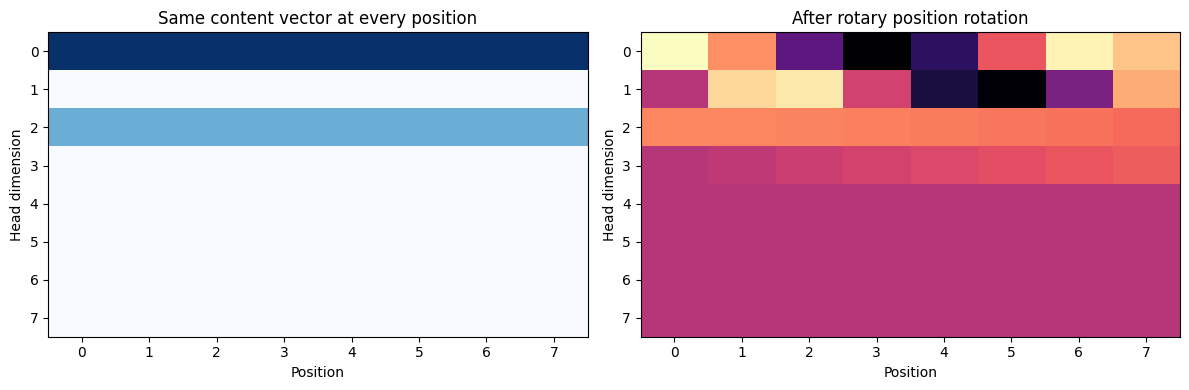

In [5]:
base_vector = torch.zeros(1, 1, 8, 8)
base_vector[..., 0] = 1.0
base_vector[..., 2] = 0.5

cos, sin = build_rope_cache(seq_len=8, head_dim=8)
rotated = apply_rope(base_vector, cos, sin)[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(base_vector[0, 0].T, aspect="auto", cmap="Blues")
axes[0].set_title("Same content vector at every position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Head dimension")

axes[1].imshow(rotated.T, aspect="auto", cmap="magma")
axes[1].set_title("After rotary position rotation")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Head dimension")

plt.tight_layout()
plt.show()


### Why RoPE Changes The Story
RoPE changes positional handling in a more structural way than additive sinusoidal PE. Instead of adding one positional vector at the input and hoping later layers preserve it, RoPE rotates `Q` and `K` inside every attention layer. That means positional structure is re-injected at each block rather than only once.

For dimension pair `i` at position `p`, the rotation angle is

$$
\theta_{p,i} = p \cdot 10000^{-2i/d}
$$

and each pair is rotated as

$$
[x_0^\prime, x_1^\prime] = [x_0 \cos \theta - x_1 \sin \theta, \; x_0 \sin \theta + x_1 \cos \theta]
$$

In code we usually do not materialize an explicit $2 \times 2$ matrix. We use the efficient identity

$$
\mathrm{RoPE}(x) = x \odot \cos(\theta) + \mathrm{rotate\_half}(x) \odot \sin(\theta)
$$

where `rotate_half` swaps even/odd coordinates and flips signs so the off-diagonal rotation terms appear element-wise. Also note that `V` is not rotated: `V` is content to be aggregated, while position should mainly affect which tokens attend to which other tokens through `QK^T`.

The key inductive bias is that the dot product between rotated vectors depends on relative offset:

$$
\mathrm{RoPE}(q, p) \cdot \mathrm{RoPE}(k, m) = f(q, k, p - m)
$$

So attention scores become functions of content and relative distance, not just absolute positions. As `|p-m|` grows, the rotations become increasingly misaligned, which often leads to a softer long-range decay in similarity and gives the model an inductive bias toward attending more strongly to nearby tokens.


### Position Encoding, Context Windows, And Memory
The usable context window of a Transformer is usually co-determined by at least three things: positional out-of-distribution behavior, the `O(n^2)` cost of attention, and whether training data actually exposed the model to long-range dependencies. Position encoding is only one part of that story, but it is often a binding constraint.

For traditional sinusoidal PE, the cache is a fixed lookup table. That is convenient because we can precompute and reuse it, but positions beyond `max_seq_len` have no entries unless we rebuild the cache, and those longer positions are out-of-distribution relative to training. Sinusoidal PE is also injected only once at the input, so across many attention and feed-forward blocks the original positional signal can become diluted. It also encodes absolute position: position `500` looks like the same absolute coordinate regardless of whether the full sequence length is `512` or `8192`.

RoPE has softer failure behavior, but it is not magic. Beyond the training length, both sinusoidal PE and RoPE face positional OOD issues. RoPE often generalizes better because nearby relative offsets remain well-behaved even when the absolute index grows, but long-context quality is still limited by what the model was trained to use. This is why changing only the positional scheme, such as with interpolation or scaling methods, can sometimes unlock longer context without full retraining: it shows the positional OOD issue was the bottleneck.

Common context-extension ideas include:
- `Position Interpolation`: compress all positions into the trained range. This is cheap, but can blur local attention geometry.
- `NTK-aware scaling`: increase the RoPE base beyond `10000` to stretch wavelengths while preserving more local detail.
- `YaRN`: treat different frequency bands differently so some are interpolated, some preserved, and some extrapolated.
- `LongRoPE` and related methods: apply non-uniform per-dimension rescaling to push context much further.

A useful high-level mental model is: positional encoding does not directly give a model better memory. It gives the model better routing tools for distance-sensitive attention decisions. Whether the model actually uses those tools well depends on training. RoPE's long-term decay is a helpful inductive bias, but it does not by itself solve forgetting.

This is also separate from the classic `lost in the middle` problem. That phenomenon is not just a positional-encoding bug: many models over-weight the beginning and end of a sequence even when positional handling is improved. Modern mitigations are usually training or systems-level fixes, such as needle-in-a-haystack training, retrieval-augmented generation, chunked or sliding-window attention, or even alternative sequence models like `Mamba` and `RWKV`. It is still an active research problem.


## Day 3: Building the Transformer Block
With attention and position handling in place, we can package the pieces into the standard block structure used throughout encoder and decoder stacks.

### Residual Connections and the Transformer Block
A Transformer block packages together self-attention, residual connections, normalization, and a feed-forward update. At a high level, the block first lets each token gather information from other tokens through attention, then refines that result with an MLP-style feed-forward network. Residual connections make both updates additive instead of replacing the old representation completely.

In simplified form, you can think of the block as

- `x = x + self_attention(x)`
- `x = x + feed_forward(x)`

Transformers also rely on LayerNorm to keep hidden-state scales stable. The exact LayerNorm formula is

$$
\mathrm{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

where $\mu$ and $\sigma^2$ are computed across the hidden dimensions of one token representation, and $\gamma$ and $\beta$ are learned scale and shift parameters. It is better to write LayerNorm this way than as division by $\mathrm{std}(x)$ because implementations explicitly normalize by $\sqrt{\sigma^2 + \epsilon}$ for numerical stability.

LayerNorm is used in Transformers because each token can be normalized independently, without depending on the rest of the batch. That makes it much more natural than BatchNorm for variable-length sequences, masking, and autoregressive inference. BatchNorm mixes statistics across different examples or token positions in the batch, which creates an unnatural coupling between tokens that may appear at the same position index but have completely different meanings or context.

The feed-forward part of the block often uses GeLU rather than ReLU. ReLU is

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

so every negative value is clamped to exactly zero. GeLU is

$$
\mathrm{GeLU}(x) = x \Phi(x)
$$

where $\Phi(x)$ is the standard Gaussian CDF. Unlike ReLU, GeLU does not hard-cut all negative inputs to zero; mildly negative values can survive with small magnitude. That smoother gating is one reason GeLU is common in modern Transformers.

This helps optimization and preserves useful information from earlier layers. To keep the setup consistent with the earlier weeks, we feed the block with the learned Week 5 embedding matrix rather than a new random embedding layer. That also means `d_model` should match the embedding width exactly, which here is `384`.

For inspection, it helps to look at two things together:
- the self-attention map: which tokens route information to which other tokens
- the per-token update size: how much each token representation changed from input to output

For one token position `t`, we measure that update size with the L2 norm

$$
\Delta_t = \lVert x_t^{\text{out}} - x_t^{\text{in}} \rVert_2
$$

A larger $\Delta_t$ means the block changed that token's representation more strongly. A smaller $\Delta_t$ means the block left it closer to its original hidden state.

Important caution: this block is still untrained in the notebook demo. So the attention maps and update norms are useful for understanding the mechanics of the architecture, but they should not be interpreted as meaningful learned linguistic behavior yet.


d_model: 384
embedded batch: (2, 96, 384)
block output: (2, 96, 384)
self-attention tensor: (2, 4, 96, 96)
example tokens: ['73', '114', '101110116', '101100</w>', '73', '65', '77', '67', '85', '82', '73', '79']
token update norms: tensor([3.8754, 4.4496, 3.8921, 4.1016, 3.8692, 4.0576, 3.9590, 3.7114, 4.0973,
        3.7054, 3.8706, 4.2654])


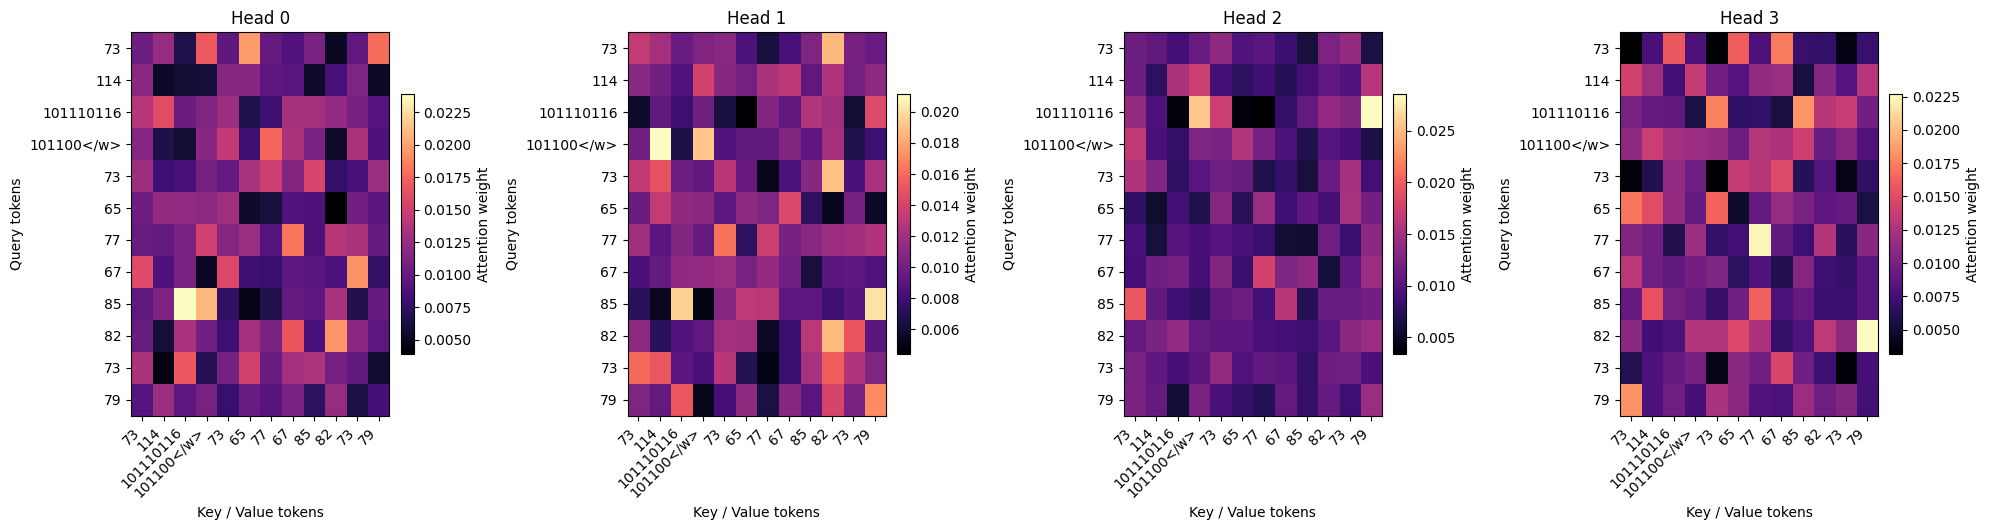

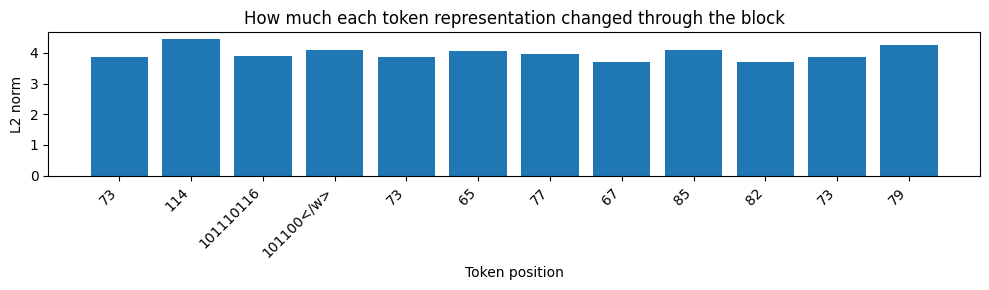

In [6]:
batch_size = 2
seq_len = 96
d_model = embedding_weight.size(1)
num_heads = 4

sample_ids = input_ids[:batch_size, :seq_len].to(device)
sample_masks = attention_masks[:batch_size, :seq_len].to(device)

sample_states = embedding_weight[sample_ids]

transformer_block = TransformerBlock(
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=4 * d_model,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=False,
).to(device)

block_output, block_attentions = transformer_block(
    x=sample_states,
    attention_mask=sample_masks,
    return_attentions=True,
)

example_idx = 0
valid_len = int(sample_masks[example_idx].sum().item())
display_len = min(12, valid_len)
example_tokens = [id_to_token[int(token_id)] for token_id in sample_ids[example_idx, :display_len].tolist()]

example_attention = block_attentions["self_attention"][example_idx:example_idx + 1, :, :display_len, :display_len].detach().cpu()
example_input = sample_states[example_idx, :display_len].detach().cpu()
example_output = block_output[example_idx, :display_len].detach().cpu()
delta_norm = (example_output - example_input).norm(dim=-1)

print("d_model:", d_model)
print("embedded batch:", tuple(sample_states.shape))
print("block output:", tuple(block_output.shape))
print("self-attention tensor:", tuple(block_attentions["self_attention"].shape))
print("example tokens:", example_tokens)
print("token update norms:", delta_norm)

plot_attention_heads(
    example_attention,
    query_tokens=example_tokens,
    key_tokens=None,
    max_heads=4,
    batch_idx=0,
)

plt.figure(figsize=(10, 3))
plt.bar(range(display_len), delta_norm.numpy())
plt.xticks(range(display_len), example_tokens, rotation=45, ha="right")
plt.ylabel("L2 norm")
plt.xlabel("Token position")
plt.title("How much each token representation changed through the block")
plt.tight_layout()
plt.show()


## Day 4: Cross-Attention with a Tiny Probe
Cross-attention needs two sequences with different roles: one sequence provides information, and the other sequence asks what to focus on. Since IMDb is not naturally paired text, we introduce a tiny handwritten probe here.

### Tiny Paired-Text Probe for Cross-Attention
IMDb is naturally a single-sequence classification dataset, so it is ideal for self-attention. For cross-attention we create a tiny paired-text probe similar in spirit to the handwritten benchmark sets from Weeks 4 and 5.

Each example has:
- a **context** sequence that provides information
- a **query** sequence that asks what to look for

That is the basic encoder-decoder pattern behind cross-attention.

In [ ]:
toy_pairs = [
    {
        "context": "the acting was fantastic but the ending was weak",
        "query": "what was positive ?",
    },
    {
        "context": "the plot was dull but the soundtrack was memorable",
        "query": "what was positive ?",
    },
    {
        "context": "the movie is not bad",
        "query": "what phrase flips sentiment ?",
    },
    {
        "context": "only the final scene is good",
        "query": "what carries the praise ?",
    },
]

all_texts = [item["context"] for item in toy_pairs] + [item["query"] for item in toy_pairs]
toy_word_vocab = build_word_vocab(all_texts)

context_ids, context_masks, context_tokens = batch_encode_word_sequences(
    [item["context"] for item in toy_pairs],
    vocab=toy_word_vocab,
    max_len=12,
)
query_ids, query_masks, query_tokens = batch_encode_word_sequences(
    [item["query"] for item in toy_pairs],
    vocab=toy_word_vocab,
    max_len=6,
)

print("context batch:", tuple(context_ids.shape))
print("query batch:", tuple(query_ids.shape))
print("toy vocab size:", len(toy_word_vocab))


### Hand-Crafted Cross-Attention Visualization
Before training any model, we can create a tiny hand-crafted semantic example so the heatmap is interpretable. The query token `positive` is given a vector that aligns with the context token `fantastic`, and the query token `weak` aligns with `weak` in the context.

In [ ]:
context_demo_tokens = ["acting", "fantastic", "ending", "weak"]
query_demo_tokens = ["positive", "weak"]

semantic_vectors = {
    "acting": torch.tensor([0.4, 0.1, 0.0, 0.0]),
    "fantastic": torch.tensor([1.0, 0.0, 0.0, 0.0]),
    "ending": torch.tensor([0.0, 0.2, 0.3, 0.0]),
    "weak": torch.tensor([0.0, 1.0, 0.0, 0.0]),
    "positive": torch.tensor([1.0, 0.0, 0.0, 0.0]),
}

context_states = torch.stack([semantic_vectors[token] for token in context_demo_tokens], dim=0).unsqueeze(0).unsqueeze(0)
query_states = torch.stack([semantic_vectors[token] for token in query_demo_tokens], dim=0).unsqueeze(0).unsqueeze(0)
values = context_states.clone()

manual_cross_output, manual_cross_attention = scaled_dot_product_attention(
    query=query_states,
    key=context_states,
    value=values,
)

print("manual cross-attention output shape:", tuple(manual_cross_output.shape))
plot_attention_heatmap(
    manual_cross_attention,
    query_tokens=query_demo_tokens,
    key_tokens=context_demo_tokens,
    title="Hand-crafted cross-attention heatmap",
    head=0,
)


### Cross-Attention Block API
Now we run the reusable `TransformerBlock` in cross-attention mode. Because the block is randomly initialized, the heatmaps are mostly about shape and mechanics rather than learned semantics.

In [ ]:
torch.manual_seed(11)

toy_embed = nn.Embedding(len(toy_word_vocab), 32).to(device)
context_states = toy_embed(context_ids.to(device))
query_states = toy_embed(query_ids.to(device))

cross_block = TransformerBlock(
    d_model=32,
    num_heads=4,
    mlp_hidden_dim=64,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=True,
).to(device)

cross_output, cross_attentions = cross_block(
    x=query_states,
    attention_mask=query_masks.to(device),
    context=context_states,
    context_mask=context_masks.to(device),
    return_attentions=True,
)

example_idx = 0
valid_q = int(query_masks[example_idx].sum().item())
valid_k = int(context_masks[example_idx].sum().item())
example_attention = cross_attentions["cross_attention"][example_idx:example_idx + 1, :, :valid_q, :valid_k].detach().cpu()

print("cross output shape:", tuple(cross_output.shape))
print("self-attention on query shape:", tuple(cross_attentions["self_attention"].shape))
print("cross-attention shape:", tuple(cross_attentions["cross_attention"].shape))
plot_attention_heads(
    example_attention,
    query_tokens=query_tokens[example_idx][:valid_q],
    key_tokens=context_tokens[example_idx][:valid_k],
    max_heads=4,
)


## Day 5: IMDb Mini-Project
The final step is to bring the reusable attention components back to the main course dataset. This section keeps the experiment intentionally small so the notebook remains approachable.

### Tiny Transformer Encoder for IMDb
We can now reuse the same building blocks for encoder-style sentiment classification on IMDb. Below we create one shared IMDb subset and compare two compact Transformer encoders.

- Model A: traditional sinusoidal positional encoding added after embeddings
- Model B: rotary positional encoding (`RoPE`) applied inside attention

To keep the notebook light, we use a small subset for the demo path. If you want a more serious experiment, increase the subset sizes and number of epochs.

### Same Dataset, Same Split, Different Positional Strategy
For a fair comparison, both models should use the exact same IMDb subset, the same train/validation split, and the same core hyperparameters. The only intentional difference should be how position information is injected.

In [ ]:
subset_size = 3072
dataset = TensorDataset(
    input_ids[:subset_size],
    attention_masks[:subset_size],
    labels[:subset_size].float(),
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(204),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

shared_model_kwargs = dict(
    vocab_size=vocab_config["vocab_size"],
    d_model=128,
    num_heads=4,
    mlp_hidden_dim=256,
    num_layers=2,
    pad_id=vocab_config["pad_id"],
    dropout=0.1,
    max_seq_len=input_ids.size(1),
)

torch.manual_seed(204)
absolute_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=False,
    use_absolute_positions=True,
).to(device)

torch.manual_seed(204)
rope_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=True,
    use_absolute_positions=False,
).to(device)

batch_ids, batch_masks, batch_labels = next(iter(train_loader))
absolute_logits, absolute_attention_stack = absolute_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)
rope_logits, rope_attention_stack = rope_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)

print("shared subset size:", len(dataset))
print("train / val sizes:", len(train_dataset), len(val_dataset))
print("absolute logits shape:", tuple(absolute_logits.shape))
print("rope logits shape:", tuple(rope_logits.shape))
print("absolute attention layers:", len(absolute_attention_stack))
print("rope attention layers:", len(rope_attention_stack))
print("absolute layer-0 attention shape:", tuple(absolute_attention_stack[0].shape))
print("rope layer-0 attention shape:", tuple(rope_attention_stack[0].shape))


In [ ]:
# Optional apples-to-apples training run
# torch.manual_seed(204)
# absolute_model = TinyTransformerClassifier(
#     **shared_model_kwargs,
#     use_rope=False,
#     use_absolute_positions=True,
# ).to(device)
# torch.manual_seed(204)
# rope_model = TinyTransformerClassifier(
#     **shared_model_kwargs,
#     use_rope=True,
#     use_absolute_positions=False,
# ).to(device)
#
# absolute_model = train_binary_classifier(
#     model=absolute_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     num_epochs=3,
#     lr=3e-4,
#     patience=2,
# )
#
# rope_model = train_binary_classifier(
#     model=rope_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     num_epochs=3,
#     lr=3e-4,
#     patience=2,
# )


## Wrap-Up
At this point we have:
- a reusable multi-head attention module
- rotary and sinusoidal positional encoding utilities
- a Transformer block with residual connections
- a cross-attention extension
- attention heatmaps for visual inspection
- a compact IMDb Transformer encoder setup

If you want to stretch this further, a good next exercise is to train two tiny IMDb models with the same hyperparameters: one using absolute positional encoding and one using `RoPE`, then compare validation behavior and attention maps.

This gives us a strong bridge into Week 7, where pretraining and transfer learning become the main story.